# SERAPH
### Secondary Structure Recognition and Prediction Hub
**Model:** CNN + BiLSTM Hybrid  
**Task:** Q3 Secondary Structure Prediction (Helix / Sheet / Coil)  
**Dataset:** train_data_new.csv / test.csv

## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import classification_report
from transformers import AutoTokenizer, EsmModel

model_name = "facebook/esm2_t12_35M_UR50D"

tokenizer = AutoTokenizer.from_pretrained(model_name)
esm2_model = EsmModel.from_pretrained(model_name)

print(f"ESM-2 Hidden Size (Embedding Dimension): {esm2_model.config.hidden_size}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using:', device)

CHECKPOINT_PATH = '/seraph_checkpoint.pt'

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ESM-2 Hidden Size (Embedding Dimension): 320
Using: cuda


## 2. Maps

In [ ]:
AA_MAP = {
  'A': 1, 'C': 2, 'E': 3, 'D': 4, 'G': 5,
  'F': 6, 'I': 7, 'H': 8, 'K': 9, 'M': 10,
  'L': 11,'N': 12,'Q': 13,'P': 14,'S': 15,
  'R': 16,'T': 17,'W': 18,'V': 19,'Y': 20,'X': 21
}

LABEL_MAP = {'H': 0, 'E': 1, 'C': 2}
IDX_TO_LABEL = {0: 'H', 1: 'E', 2: 'C'}
PADDING_IDX = -100
PADDING_LABEL = -100

## 3. Data Loading

### Dataset Source

This project utilizes the **[Protein Secondary Structure Prediction dataset from Kaggle](https://www.kaggle.com/datasets/tranminhthuan/protein-dataset)**.

In [ ]:
def load_data(path, is_test=False):
    df = pd.read_csv(path)
    drop_cols = ['Unnamed: 0', 'sst8', 'source'] if not is_test else ['Unnamed: 0', 'sst8']
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
    df.columns = ['seq', 'sst3', 'seq_len'] if not is_test else ['seq', 'sst3', 'seq_len']
    print(f'Loaded {len(df)} proteins from {path}')
    print(df.head(2))
    return df

train_df = load_data('/content/train_data_new.csv')
test_df  = load_data('/content/test.csv', is_test=True)

Loaded 16806 proteins from /content/train_data_new.csv
                                                 seq  \
0  AAPANAVTADDPTAIALKYNQDATKSERVAAARPGLPPEEQHCANC...   
1     TTCCPSIVARSNFNVCRLPGTPEALCATYTGCIIIPGATCPGDYAN   

                                                sst3  seq_len  
0  CCCCCECCCCCHHHHHHCCECCHHHCCHHHHCCCCCCHHHCCHHHE...       83  
1     CEECCCHHHHHHHHHHHCCCCCHHHHHHHHCCEECCCCCCCCCCCC       46  
Loaded 514 proteins from /content/test.csv
                                                 seq  \
0  VPSLATISLENSWSGLSKQIQLAQGNNGIFRTPIVLVDNKGNRVQI...   
1  MFKVYGYDSNIHKCVYCDNAKRLLTVKKQPFEFINIMPEKGVFDDE...   

                                                sst3  seq_len  
0  CCCHHHHHHHHHHHHHHHHHHHHCCCCCEEEEEEEECCCCCCCEEE...       67  
1  CEEEEECCCCCCCCHHHHHHHHHHHHCCCCEEEEECCCECCECCHH...       87  


## 4. Encoding

In [ ]:
def encode(df):
    seq_enc = df['seq']
    lbl_enc = df['sst3'].apply(
        lambda x: torch.tensor([LABEL_MAP[i] for i in x], dtype=torch.long)
    )
    return seq_enc, lbl_enc

train_seq, train_lbl = encode(train_df)
test_seq,  test_lbl  = encode(test_df)

print('Train samples:', len(train_seq))
print('Test samples: ', len(test_seq))
print('Example seq (first 10):', train_seq[0][:10])
print('Example lbl (first 10):', train_lbl[0][:10])

Train samples: 16806
Test samples:  514
Example seq (first 10): AAPANAVTAD
Example lbl (first 10): tensor([2, 2, 2, 2, 2, 1, 2, 2, 2, 2])


## 5. Dataset & DataLoader

In [ ]:
class ProteinDataset(Dataset):
    def __init__(self, seqs, labels):
        self.seqs   = seqs.tolist()
        self.labels = labels.tolist()
    def __len__(self):
        return len(self.seqs)
    def __getitem__(self, idx):
      sequence = self.seqs[idx]
      label = torch.cat([
          torch.tensor([-100]),
          self.labels[idx],
          torch.tensor([-100])
      ])

      return sequence, label

def collate_fn(batch):
    seqs, labels = zip(*batch)
    tokenized = tokenizer(
        list(seqs),
        padding=True,
        truncation=True,
        return_tensors="pt")
    return (
        tokenized['input_ids'],
        tokenized['attention_mask'],
        pad_sequence(labels, batch_first=True, padding_value=PADDING_LABEL)
    )

BATCH_SIZE = 32

train_loader = DataLoader(
    ProteinDataset(train_seq, train_lbl),
    batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn
)
test_loader = DataLoader(
    ProteinDataset(test_seq, test_lbl),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)

# sanity check
s, m, l = next(iter(train_loader))
print('Batch seq shape:  ', s.shape)
print('Batch mask shape:  ', m.shape)
print('Batch label shape:', l.shape)

Batch seq shape:   torch.Size([32, 494])
Batch mask shape:   torch.Size([32, 494])
Batch label shape: torch.Size([32, 494])


## 6. Model — SERAPH (ESM-2 Embeddings + CNN + BiLSTM)

In [ ]:
class SERAPH(nn.Module):
    def __init__(
        self,
        esm_model,
        conv_channels=256,
        kernel_size=7,
        lstm_hidden=256,
        num_classes=3,
        dropout=0.3,
        freeze_esm=True
    ):
        super().__init__()
        self.esm = esm_model

        if freeze_esm:
          for param in self.esm.encoder.layer[:-2].parameters():
              param.requires_grad = False

        esm_embed_dim=self.esm.config.hidden_size

        self.conv = nn.Conv1d(esm_embed_dim, conv_channels, kernel_size=kernel_size, padding=kernel_size//2)
        self.bn = nn.BatchNorm1d(conv_channels)
        self.dropout = nn.Dropout(dropout)
        self.bilstm = nn.LSTM(
            conv_channels, lstm_hidden,
            num_layers=2,batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(lstm_hidden * 2, num_classes)

    def forward(self, input_ids, attention_mask=None):
        outputs = self.esm(input_ids=input_ids, attention_mask=attention_mask)
        x = outputs.last_hidden_state
        x = x.transpose(1, 2) # (B, embed_dim, L)
        x = torch.relu(self.bn(self.conv(x))) # (B, conv_channels, L)
        x = self.dropout(x)
        x = x.transpose(1, 2) # (B, L, conv_channels)
        x, _ = self.bilstm(x) # (B, L, lstm_hidden*2)
        x = self.dropout(x)
        return self.fc(x) # (B, L, num_classes)

In [ ]:
model = SERAPH(esm_model=esm2_model).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'SERAPH ready | Trainable parameters: {total_params:,}')
print(model)

SERAPH ready | Trainable parameters: 3,205,379
SERAPH(
  (esm): EsmModel(
    (embeddings): EsmEmbeddings(
      (word_embeddings): Embedding(33, 320, padding_idx=1)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): EsmEncoder(
      (layer): ModuleList(
        (0-5): 6 x EsmLayer(
          (attention): EsmAttention(
            (self): EsmSelfAttention(
              (query): Linear(in_features=320, out_features=320, bias=True)
              (key): Linear(in_features=320, out_features=320, bias=True)
              (value): Linear(in_features=320, out_features=320, bias=True)
              (rotary_embeddings): RotaryEmbedding()
            )
            (output): EsmSelfOutput(
              (dense): Linear(in_features=320, out_features=320, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (LayerNorm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
          )
          (intermediate): EsmIntermediate(
            (d

## 7. Training Config

In [ ]:
EPOCHS = 15
LR = 5e-5

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4, fused=True)
weights = torch.tensor([1.3, 1.3, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights, ignore_index=PADDING_LABEL)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

print('Optimizer:', optimizer)
print('Scheduler: ReduceLROnPlateau | patience=3 | factor=0.5')

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: True
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler: ReduceLROnPlateau | patience=3 | factor=0.5


## 8. Training Loop

In [ ]:
best_acc = 0.0
start_epoch = 0
history = {'train_loss': [], 'train_acc': []}
save_checkpoint = False

for epoch in range(start_epoch, EPOCHS):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for seqs, mask, labels in train_loader:
        seqs, mask, labels = seqs.to(device), mask.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(seqs, mask) # (B, L, 3)
        loss = criterion(outputs.view(-1, 3), labels.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=-1)
        mask = labels != PADDING_LABEL
        correct += (preds[mask] == labels[mask]).sum().item()
        total += mask.sum().item()

    acc = correct / total * 100
    avg_loss = total_loss / len(train_loader)
    history['train_loss'].append(avg_loss)
    history['train_acc'].append(acc)

    scheduler.step(avg_loss)

    # save best checkpoint
    if acc > best_acc:
      best_acc = acc
    if save_checkpoint:
      torch.save({
          'epoch': epoch,
          'model_state_dict': model.state_dict(),
          'optimizer_state_dict': optimizer.state_dict(),
          'acc': acc,
      }, CHECKPOINT_PATH)
      print(f'Epoch {epoch+1:02}/{EPOCHS} | Loss: {avg_loss:.4f} | Acc: {acc:.2f}% ✓ saved')
    else:
      print(f'Epoch {epoch+1:02}/{EPOCHS} | Loss: {avg_loss:.4f} | Acc: {acc:.2f}%')

print(f'\nBest train accuracy: {best_acc:.2f}%')

Epoch 01/15 | Loss: 0.5418 | Acc: 75.74%
Epoch 02/15 | Loss: 0.5131 | Acc: 77.04%
Epoch 03/15 | Loss: 0.5081 | Acc: 77.26%
Epoch 04/15 | Loss: 0.5023 | Acc: 77.50%
Epoch 05/15 | Loss: 0.5008 | Acc: 77.59%
Epoch 06/15 | Loss: 0.4978 | Acc: 77.74%
Epoch 07/15 | Loss: 0.4955 | Acc: 77.82%
Epoch 08/15 | Loss: 0.4937 | Acc: 77.90%
Epoch 09/15 | Loss: 0.4936 | Acc: 77.93%
Epoch 10/15 | Loss: 0.4920 | Acc: 77.97%
Epoch 11/15 | Loss: 0.4911 | Acc: 77.98%
Epoch 12/15 | Loss: 0.4896 | Acc: 78.06%
Epoch 13/15 | Loss: 0.4888 | Acc: 78.10%
Epoch 14/15 | Loss: 0.4883 | Acc: 78.15%
Epoch 15/15 | Loss: 0.4886 | Acc: 78.10%

Best train accuracy: 78.15%


## 9. Evaluation on Test Set

In [ ]:
# load best checkpoint before evaluating
if save_checkpoint:
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
  model.load_state_dict(checkpoint['model_state_dict'])

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for seqs, mask, labels in test_loader:
        seqs, mask, labels = seqs.to(device),mask.to(device), labels.to(device)
        outputs = model(seqs, mask)
        preds = outputs.argmax(dim=-1)
        mask = labels != PADDING_LABEL
        all_preds.extend(preds[mask].cpu().numpy())
        all_labels.extend(labels[mask].cpu().numpy())

q3_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels) * 100
print(f'Q3 Accuracy: {q3_acc:.2f}%\n')
print(classification_report(
    all_labels, all_preds,
    target_names=['Helix (H)', 'Sheet (E)', 'Coil (C)']
))

Q3 Accuracy: 75.69%

              precision    recall  f1-score   support

   Helix (H)       0.78      0.85      0.81     29319
   Sheet (E)       0.67      0.77      0.71     19197
    Coil (C)       0.80      0.68      0.73     36249

    accuracy                           0.76     84765
   macro avg       0.75      0.76      0.75     84765
weighted avg       0.76      0.76      0.76     84765



## 10. Training Curves

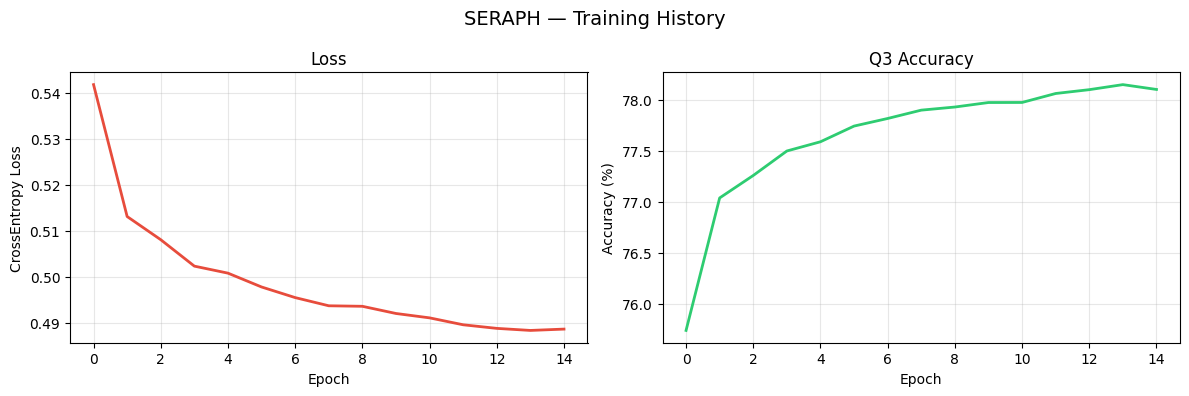

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('SERAPH — Training History', fontsize=14)

ax1.plot(history['train_loss'], color='#e74c3c', linewidth=2)
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('CrossEntropy Loss')
ax1.grid(alpha=0.3)

ax2.plot(history['train_acc'], color='#2ecc71', linewidth=2)
ax2.set_title('Q3 Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('seraph_training_curves.png', dpi=150)
plt.show()

### 11. Inference — Predict on a Raw Sequence

In [ ]:
def predict(sequence: str, model, device) -> dict:
    """
    Takes a raw amino acid sequence string.
    Returns per-residue secondary structure labels.
    """
    model.eval()
    encoded = torch.tensor(
        [AA_MAP.get(aa, 21) for aa in sequence.upper()],
        dtype=torch.long
    ).unsqueeze(0).to(device) # (1, seq_len)

    with torch.no_grad():
        output = model(encoded) # (1, seq_len, 3)
        probs = torch.softmax(output, dim=-1)
        preds = output.argmax(dim=-1)[0] # (seq_len,)

    labels = [IDX_TO_LABEL[p.item()] for p in preds]

    return {
        'sequence': sequence,
        'prediction': ''.join(labels),
        'probs': probs[0].cpu().numpy()
    }

# example
seq    = 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG'
result = predict(seq, model, device)

print('Sequence:  ', result['sequence'][:60], '...')
print('Structure: ', result['prediction'][:60], '...')
print()

# pretty print aligned
chunk = 60
for i in range(0, len(seq), chunk):
    print('SEQ:', result['sequence'][i:i+chunk])
    print('STR:', result['prediction'][i:i+chunk])
    print()

Sequence:   MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYN ...
Structure:  CCCCCECCCCCCCCCEECCEEEEEEEEEEEEEEECCCCCCCCEECEEECHHHEECEEEEE ...

SEQ: MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYN
STR: CCCCCECCCCCCCCCEECCEEEEEEEEEEEEEEECCCCCCCCEECEEECHHHEECEEEEE

SEQ: IQKESTLHLVLRLRGG
STR: EECCCCCEEEEEECCC



In [ ]:
sst = "CEEEEEECCCCEEEEECCCCCCHHHHHHHHHHHHCCCHHHEEEEECCEECCCCCCHHHHCCCCCCEEEEEECCCCC"

def check_predictions(original, predicted):
  if len(original) != len(predicted):
    return "Error: Sequences must be the same length!"

  correct = 0
  total = len(original)
  markers = []

  for i in range(total):
    if original[i] == predicted[i]:
      correct += 1
      markers.append(" ") # Correct
    else:
      markers.append("!") # Incorrect

  accuracy = (correct / total) * 100

  print(f"--- Model Performance Report ---")
  print(f"Total Amino Acids: {total}")
  print(f"Correct Predictions: {correct}")
  print(f"Accuracy: {accuracy:.2f}%")
  print("-" * 30)
  print(f"Target:    {original}")
  print(f"Predicted: {''.join(predicted)}")
  print(f"Errors:    {''.join(markers)}")
  print("-" * 30)

check_predictions(sst, result['prediction'])

--- Model Performance Report ---
Total Amino Acids: 76
Correct Predictions: 26
Accuracy: 34.21%
------------------------------
Target:    CEEEEEECCCCEEEEECCCCCCHHHHHHHHHHHHCCCHHHEEEEECCEECCCCCCHHHHCCCCCCEEEEEECCCCC
Predicted: CCCCCECCCCCCCCCEECCEEEEEEEEEEEEEEECCCCCCCCEECEEECHHHEECEEEEEEECCCCCEEEEEECCC
Errors:     !!!! !    !!!! !  !!!!!!!!!!!!!!!   !!!!!  !!! !!!!!! !!!!!!!   !!    !!   
------------------------------


###12. Saving the Model

In [ ]:
settings = {
    'epoch': epoch + 1,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'best_acc': best_acc,
    'history': history,
}

torch.save(settings, CHECKPOINT_PATH)

print(f"🏆 New best model saved to {CHECKPOINT_PATH} (Acc: {best_acc:.2f}%)")

🏆 New best model saved to /seraph_checkpoint.pt (Acc: 78.15%)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# You can specify any folder name you like
CHECKPOINT_PATH = "/content/drive/MyDrive/seraph_fast_best.pth"

In [ ]:
settings = {
    'epoch': epoch + 1,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'best_acc': best_acc,
    'history': history,
}

torch.save(settings, CHECKPOINT_PATH)

print(f"🏆 New best model saved to {CHECKPOINT_PATH} (Acc: {best_acc:.2f}%)")

🏆 New best model saved to /content/drive/MyDrive/seraph_fast_best.pth (Acc: 78.15%)
